In [5]:
import numpy as np
import matplotlib.pyplot as plt

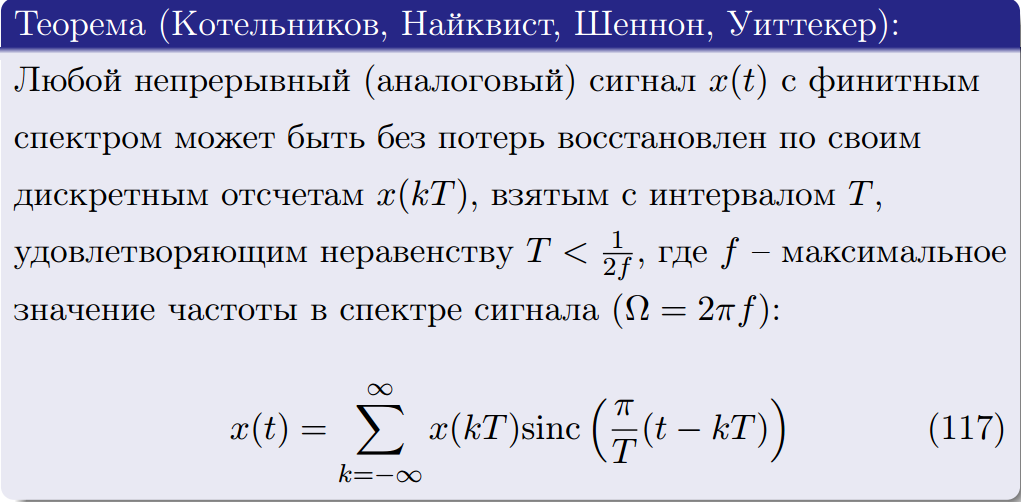

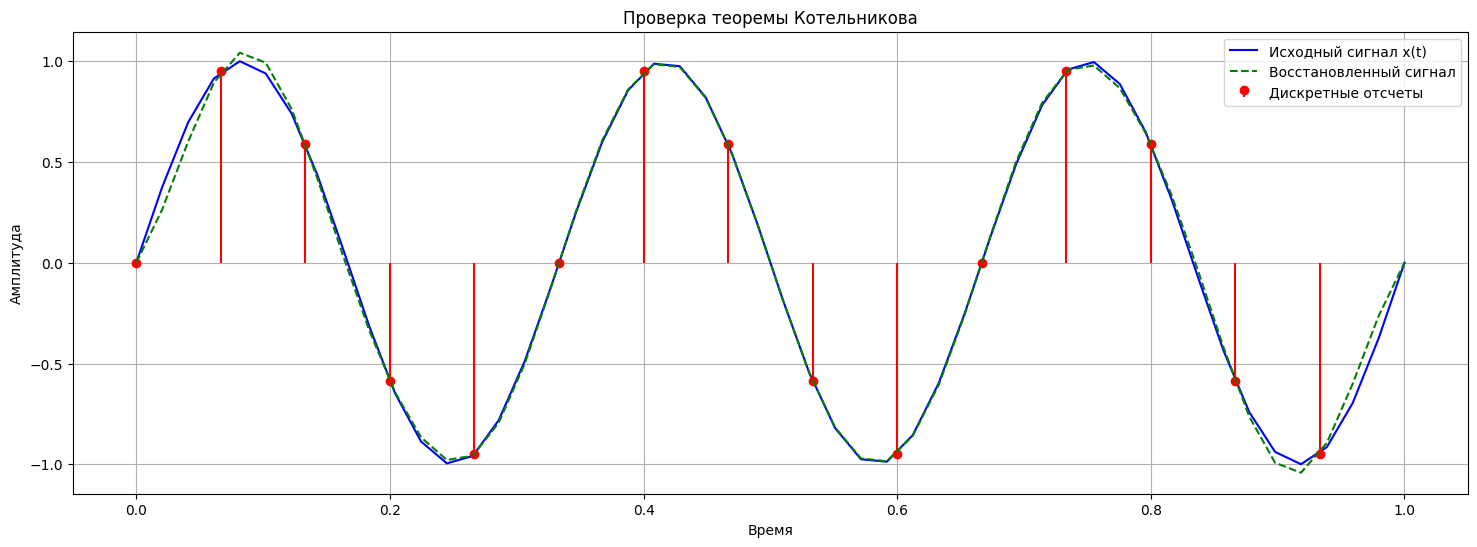

In [13]:
f0 = 3
w0 = 2 * np.pi * f0
fs = f0 * 5
T = 1/fs

t = np.linspace(0,1,50)
t_samples = np.arange(0, 1, T)
x = np.sin(w0 * t)
x_samples = np.sin(w0 * t_samples)

x_history = np.zeros_like(t)
for n, i in enumerate(x_samples):
    x_history += i * np.sinc(1/T*(t-n*T))


plt.figure(figsize=(18, 6))
plt.plot(t, x, "b", label="Исходный сигнал x(t)")
plt.stem(
    t_samples,
    x_samples,
    linefmt="r",
    markerfmt="ro",
    basefmt=" ",
    label="Дискретные отсчеты",
)
plt.plot(t, x_history, "g--", label="Восстановленный сигнал")
plt.title("Проверка теоремы Котельникова")
plt.xlabel("Время")
plt.ylabel("Амплитуда")
plt.grid()
plt.legend(loc="upper right")
plt.show()

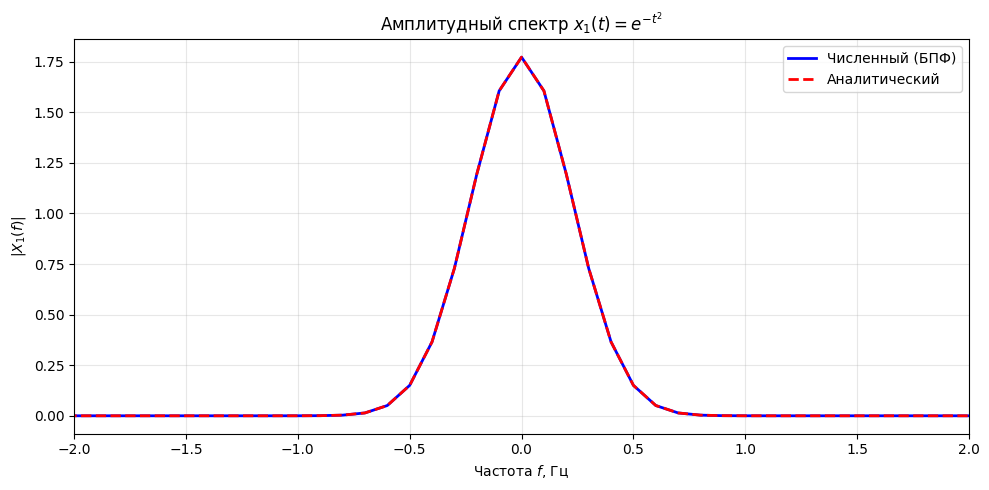

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Параметры
N = 1024
T = 10.0
dt = T / N
t = np.linspace(-T/2, T/2, N, endpoint=False)  # симметричный интервал

# Сигнал
x1 = np.exp(-t**2)
# Сдвиг по t
x1_shifted = np.fft.ifftshift(x1)
# 
fft_x1 = np.fft.fft(x1_shifted) * dt
# fftshift центрирует спектр для отображения
fft_x1_shifted = np.fft.fftshift(fft_x1)

# Частотная ось
freq = np.fft.fftfreq(N, dt)
freq_shifted = np.fft.fftshift(freq)

# Для конвенции X(f) = ∫x(t)·e^(-j2πft)dt: F{e^(-t²)} = √π·e^(-π²f²)
X1_analytic = np.sqrt(np.pi) * np.exp(-np.pi**2 * freq_shifted**2)

plt.figure(figsize=(10, 5))
plt.plot(freq_shifted, np.abs(fft_x1_shifted), "b", label="Численный (БПФ)", linewidth=2)
plt.plot(freq_shifted, X1_analytic, "r--", label="Аналитический", linewidth=2)
plt.title("Амплитудный спектр $x_1(t) = e^{-t^2}$")
plt.xlabel("Частота $f$, Гц")
plt.ylabel("$|X_1(f)|$")
plt.xlim(-2, 2)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

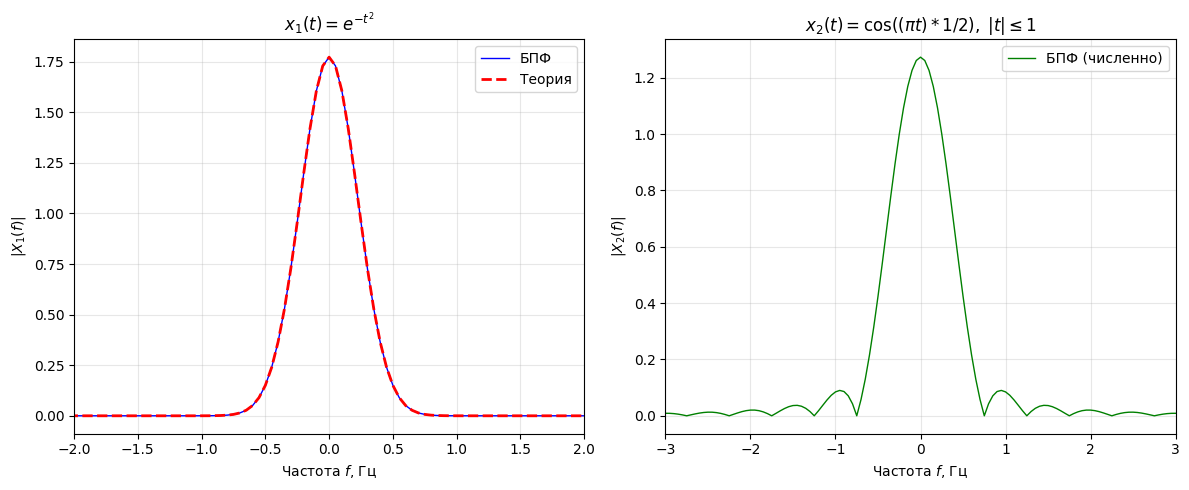

In [ ]:
# Параметры
N = 2048
T = 20.0
dt = T / N
t = np.linspace(-T/2, T/2, N, endpoint=False)
freq = np.fft.fftshift(np.fft.fftfreq(N, dt))

# === x1(t) ===
x1 = np.exp(-t**2)
X1_num = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(x1)) * dt)
X1_anal = np.sqrt(np.pi) * np.exp(-np.pi**2 * freq**2)

# === x2(t) — чирп по заданию ===
x2 = np.where(np.abs(t) <= 1, np.cos((np.pi * t)/2), 0)
X2_num = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(x2)) * dt)

# === Построение ===
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(freq, np.abs(X1_num), 'b', label='БПФ', linewidth=1)
plt.plot(freq, X1_anal, 'r--', label='Теория', linewidth=2)
plt.title('$x_1(t) = e^{-t^2}$')
plt.xlabel('Частота $f$, Гц')
plt.ylabel('$|X_1(f)|$')
plt.xlim(-2, 2)
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(freq, np.abs(X2_num), 'g', label='БПФ (численно)', linewidth=1)
plt.title('$x_2(t) = \cos((\pi t)*1/2),\; |t|\leq 1$')
plt.xlabel('Частота $f$, Гц')
plt.ylabel('$|X_2(f)|$')
plt.xlim(-3, 3)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

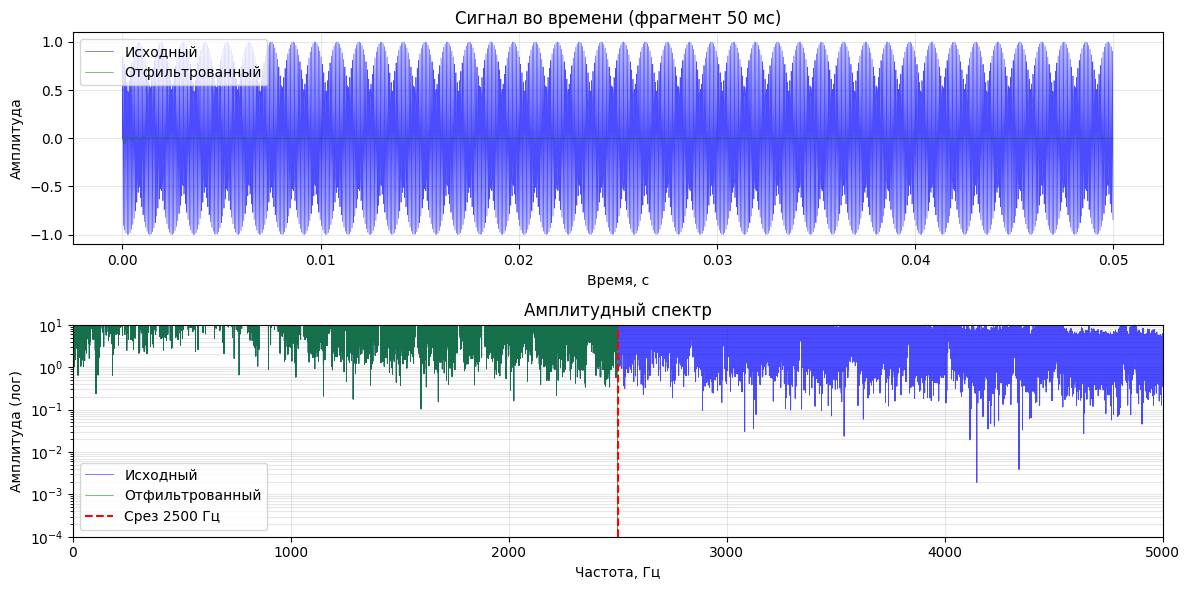

✅ Сохранено: tune_result.wav (ФНЧ срез: 2500 Гц)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile

# Загрузка
fs, signal = wavfile.read("tune.wav")
if signal.ndim > 1:
    signal = signal.mean(axis=1)
signal = signal.astype(np.float64)
signal = signal / np.max(np.abs(signal))

n = len(signal)
t = np.arange(n) / fs

# Спектр
spectrum = np.fft.fft(signal)
freq = np.fft.fftfreq(n, 1/fs)
amplitude = np.abs(spectrum)

# Вариант 1: ФНЧ (как у вас) — если помеха ВЫСОКОЧАСТОТНАЯ
cutoff_freq = 2500  # Гц — частота среза
cutoff_idx = int(cutoff_freq * n / fs)
filtered_spectrum = spectrum.copy()
filtered_spectrum[cutoff_idx : n - cutoff_idx] = 0

# Обратное преобразование
filtered_signal = np.real(np.fft.ifft(filtered_spectrum))
filtered_signal = filtered_signal / np.max(np.abs(filtered_signal))

# 📊 Визуализация
plt.figure(figsize=(12, 6))

# Временная область (фрагмент 50 мс)
window = int(0.05 * fs)
plt.subplot(2, 1, 1)
plt.plot(t[:window], signal[:window], 'b', linewidth=0.5, label='Исходный', alpha=0.7)
plt.plot(t[:window], filtered_signal[:window], 'g', linewidth=0.5, label='Отфильтрованный', alpha=0.7)
plt.title("Сигнал во времени (фрагмент 50 мс)")
plt.xlabel("Время, с"); plt.ylabel("Амплитуда")
plt.ylim(-1.1, 1.1); plt.legend(); plt.grid(alpha=0.3)

# Спектр
plt.subplot(2, 1, 2)
freq_limit = 5000
mask = np.abs(freq) <= freq_limit
plt.semilogy(np.abs(freq[mask]), amplitude[mask], 'b', linewidth=0.5, label='Исходный', alpha=0.7)
plt.semilogy(np.abs(freq[mask]), np.abs(filtered_spectrum[mask]), 'g', linewidth=0.5, label='Отфильтрованный', alpha=0.7)
plt.axvline(cutoff_freq, color='r', linestyle='--', label=f'Срез {cutoff_freq} Гц')
plt.title("Амплитудный спектр"); plt.xlabel("Частота, Гц"); plt.ylabel("Амплитуда (лог)")
plt.xlim(0, freq_limit); plt.ylim(1e-4, 1e1); plt.legend(); plt.grid(alpha=0.3, which='both')

plt.tight_layout(); plt.show()

# 💾 Сохранение
wavfile.write("tune_result.wav", fs, (filtered_signal * 32767).astype(np.int16))
print(f"✅ Сохранено: tune_result.wav (ФНЧ срез: {cutoff_freq} Гц)")